Файл не найден, использую стандартное изображение grace_hopper.jpg
Форма исходного изображения: (600, 512, 3)

Оценка сжатия:
Исходный размер: 921600 байт
r=  1: сжатый размер =    13356 байт, коэффициент сжатия =  69.00
r=  5: сжатый размер =    66780 байт, коэффициент сжатия =  13.80
r= 10: сжатый размер =   133560 байт, коэффициент сжатия =   6.90
r= 30: сжатый размер =   400680 байт, коэффициент сжатия =   2.30
r=100: сжатый размер =  1335600 байт, коэффициент сжатия =   0.69
r=512: сжатый размер =  6838272 байт, коэффициент сжатия =   0.13


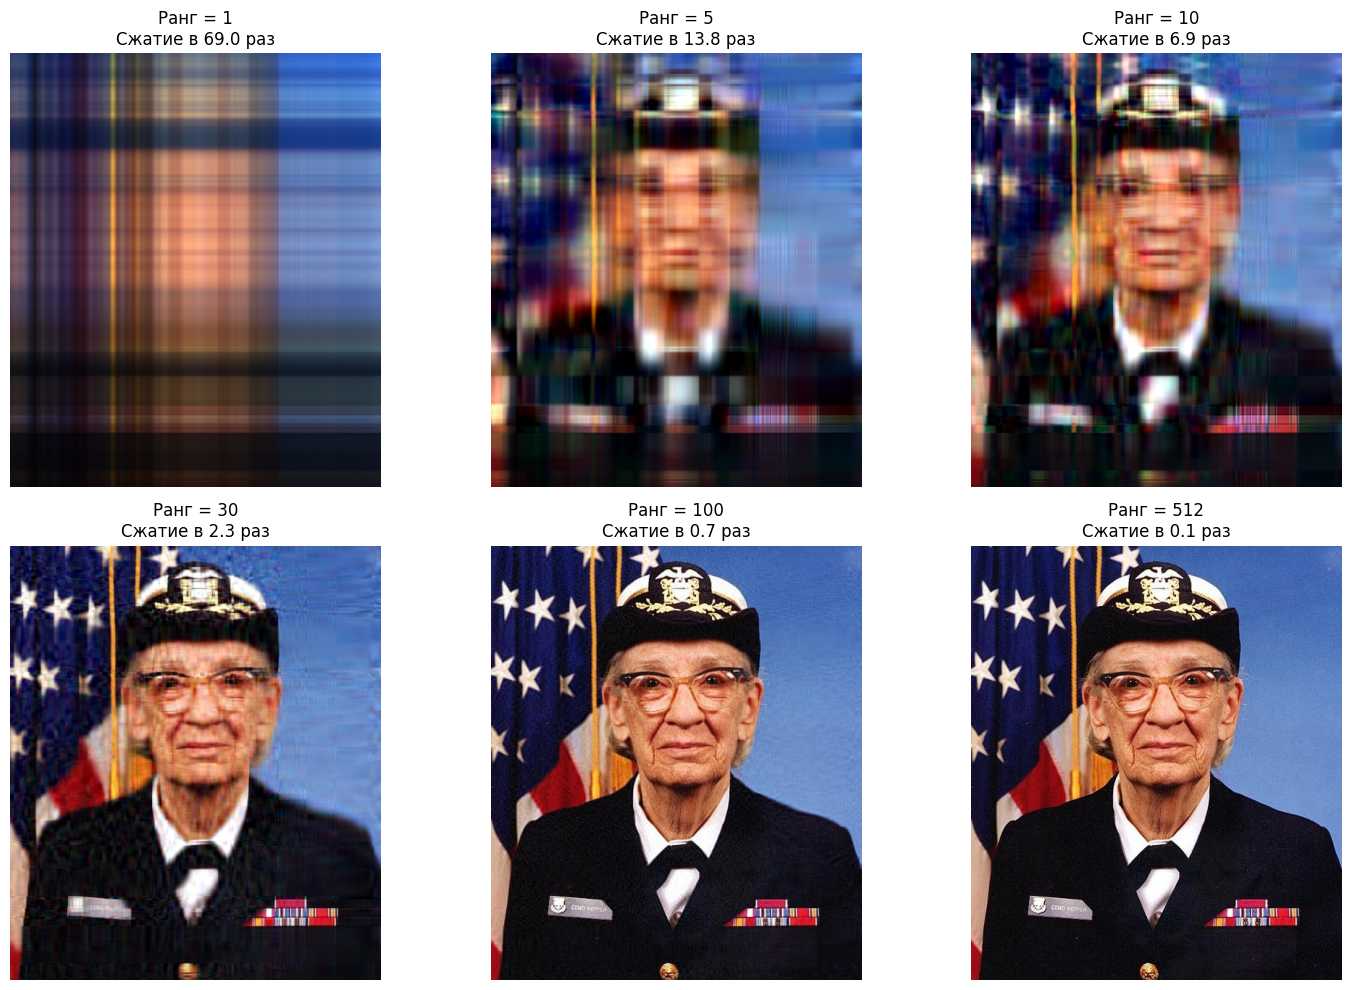

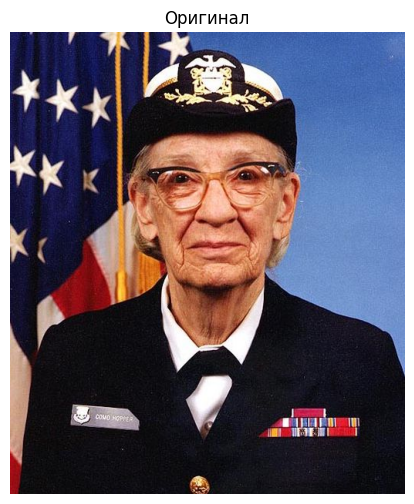

Все автоматические проверки пройдены. Задание выполнено корректно!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# Часть А. Загрузка и подготовка данных
# ============================================================

IMG_PATH = "my_pic.jpg"   # <-- замените на путь к своей картинке
USE_RGB = True            # True: RGB, False: grayscale

try:
    img = Image.open(IMG_PATH)
except FileNotFoundError:
    import matplotlib.cbook as cbook
    img = Image.open(cbook.get_sample_data("grace_hopper.jpg"))
    print("Файл не найден, использую стандартное изображение grace_hopper.jpg")

img = img.convert("RGB" if USE_RGB else "L")
original = np.array(img)
original_shape = original.shape
h, w = original.shape[:2]
c = original.shape[2] if original.ndim == 3 else 1

print("Форма исходного изображения:", original_shape)

# ============================================================
# Часть Б. SVD и восстановление для разных рангов
# ============================================================

def svd_approx_2d(channel, r):
    """SVD-аппроксимация одной 2D-матрицы ранга r."""
    U, s, Vt = np.linalg.svd(channel.astype(np.float64), full_matrices=False)
    return (U[:, :r] * s[:r]) @ Vt[:r, :]

def svd_approx_image(image, r):
    """SVD-аппроксимация изображения: серого или RGB."""
    if image.ndim == 2:
        return svd_approx_2d(image, r)
    else:
        channels = [
            svd_approx_2d(image[:, :, i], r)
            for i in range(image.shape[2])
        ]
        return np.stack(channels, axis=2)

max_rank = min(h, w)
list_of_ranks = [1, 5, 10, 30, 100, max_rank]
list_of_ranks = sorted(set(r for r in list_of_ranks if r <= max_rank))

approximations = [svd_approx_image(original, r) for r in list_of_ranks]

# ============================================================
# Часть Г. Подсчёт эффективности сжатия
# ============================================================

def compressed_size_bytes(h, w, c, r, bytes_per_num=4):
    return r * (h + 1 + w) * c * bytes_per_num

original_size_bytes = h * w * c

compressed_sizes = []
compression_ratios = []

for r in list_of_ranks:
    comp_size = compressed_size_bytes(h, w, c, r)
    compressed_sizes.append(comp_size)
    compression_ratios.append(original_size_bytes / comp_size)

print("\nОценка сжатия:")
print(f"Исходный размер: {original_size_bytes} байт")
for r, size, ratio in zip(list_of_ranks, compressed_sizes, compression_ratios):
    print(f"r={r:3d}: сжатый размер = {size:8.0f} байт, коэффициент сжатия = {ratio:6.2f}")

# ============================================================
# Часть В. Визуализация
# ============================================================

plt.figure(figsize=(15, 10))

for i, (r, approx) in enumerate(zip(list_of_ranks, approximations), 1):
    plt.subplot(2, 3, i)
    show = np.clip(approx, 0, 255).astype(np.uint8)
    if show.ndim == 2:
        plt.imshow(show, cmap="gray")
    else:
        plt.imshow(show)
    plt.title(f"Ранг = {r}\nСжатие в {compression_ratios[i-1]:.1f} раз")
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
if original.ndim == 2:
    plt.imshow(original, cmap="gray")
else:
    plt.imshow(original)
plt.title("Оригинал")
plt.axis("off")
plt.show()

# ============================================================
# Обязательная автопроверка (с заменой sklearn на numpy)
# ============================================================

original_flat = original.flatten()

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, \
        f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка диапазона 0-255
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255)
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка монотонности MSE (используем numpy вместо sklearn)
mse_list = []
for i in range(len(approximations)):
    # Формула MSE: среднее от квадрата разности
    mse = np.mean((original_flat - approximations[i].flatten()) ** 2)
    mse_list.append(mse)

for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, \
        f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("Все автоматические проверки пройдены. Задание выполнено корректно!")